<a href="https://colab.research.google.com/github/Mahammad-Haroon/Data-Analysis-Projects/blob/main/Decision_Tree_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import the required libraries

In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

#Load the Iris dataset

In [2]:
load_iris()

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
# Load the built-in Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature names:")
print(feature_names)

print("\nTarget names:")
print(target_names)

print("\nDataset shape:")
print(X.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


## What happens here?

The Iris dataset contains:

150 records
4 features
3 classes

The four features are:

sepal length
sepal width
petal length
petal width

You don't have to download a CSV.

Scikit-learn loads the dataset directly.

#Convert it into a binary classification problem

In [4]:
# Keep only two classes: 0 and 1

binary_mask = y < 2

X_binary = X[binary_mask]
y_binary = y[binary_mask]

print("Binary dataset shape:", X_binary.shape)
print("Classes present:", np.unique(y_binary))

Binary dataset shape: (100, 4)
Classes present: [0 1]


# Split the dataset into training and testing data

In [5]:
# Split the data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


#Train the constrained Decision Tree

In [6]:
# Create a constrained Decision Tree

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Train the model

model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


#Check training and testing accuracy

In [7]:
# Make predictions

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0


#Visualize the complete Decision Tree

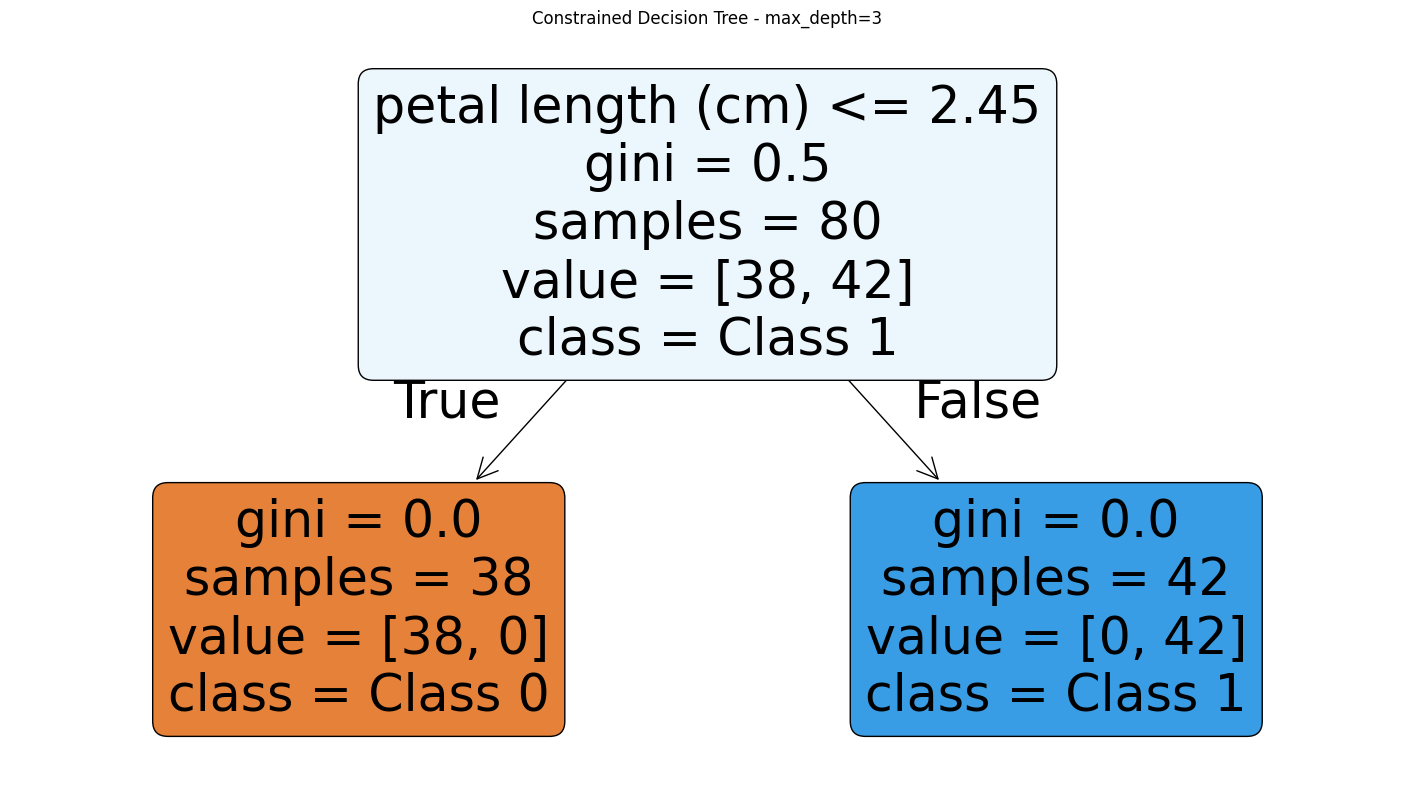

In [8]:
# Visualize the trained Decision Tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=2
)

plt.title("Constrained Decision Tree - max_depth=3")
plt.show()

#Step 8 — Extract Feature Importance

In [9]:
# Extract feature importance

importances = model.feature_importances_

print("Feature Importances:")
print("---------------------")

for feature, importance in zip(feature_names, importances):
    print(f"{feature}: {importance:.6f}")

print("\nTotal Importance:", importances.sum())

Feature Importances:
---------------------
sepal length (cm): 0.000000
sepal width (cm): 0.000000
petal length (cm): 1.000000
petal width (cm): 0.000000

Total Importance: 1.0


#Step 9 — Find the most important feature automatically

To make your assignment stronger, add:

In [10]:
# Find the most important feature

most_important_index = np.argmax(importances)

print(
    "\nMost Important Feature:",
    feature_names[most_important_index]
)

print(
    "Importance Weight:",
    f"{importances[most_important_index]:.6f}"
)


Most Important Feature: petal length (cm)
Importance Weight: 1.000000


#Select the first test sample

The assignment specifically says:

Select the very first row from your test set (X_test[0]).

In [11]:
# Select the first test sample

sample = X_test[0]
actual_class = y_test[0]

print("First Test Sample:")
print("------------------")

for feature, value in zip(feature_names, sample):
    print(f"{feature}: {value}")

print("\nActual Class:", actual_class)

prediction = model.predict([sample])[0]

print("Predicted Class:", prediction)

First Test Sample:
------------------
sepal length (cm): 6.0
sepal width (cm): 2.7
petal length (cm): 5.1
petal width (cm): 1.6

Actual Class: 1
Predicted Class: 1


#Programmatically trace the prediction path

In [12]:
# Programmatically trace the prediction path

tree = model.tree_

node_indicator = model.decision_path([sample])
leaf_id = model.apply([sample])[0]

node_index = node_indicator.indices[
    node_indicator.indptr[0]:node_indicator.indptr[1]
]

print("Prediction Path")
print("================")

for node_id in node_index:

    # Check whether this is a leaf node
    if leaf_id == node_id:
        print(
            f"Node {node_id}: FINAL LEAF -> "
            f"Predicted Class {prediction}"
        )
        continue

    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]

    feature_value = sample[feature_index]

    if feature_value <= threshold:
        direction = "TRUE -> Go LEFT"
    else:
        direction = "FALSE -> Go RIGHT"

    print(
        f"Node {node_id}: "
        f"{feature_names[feature_index]} = {feature_value:.2f} "
        f"<= {threshold:.2f} ? "
        f"{direction}"
    )

Prediction Path
Node 0: petal length (cm) = 5.10 <= 2.45 ? FALSE -> Go RIGHT
Node 2: FINAL LEAF -> Predicted Class 1


#Step 12 — Create a cleaner human-readable trace

In [13]:
# Human-readable prediction trace

print("\n===== HUMAN-READABLE TRACE =====")

for node_id in node_index:

    if leaf_id == node_id:
        print(
            f"Final Leaf Node {node_id}: "
            f"Predicted Class = {prediction}"
        )
        break

    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_value = sample[feature_index]

    if feature_value <= threshold:

        print(
            f"Node {node_id}: "
            f"{feature_names[feature_index]} = {feature_value:.2f} "
            f"<= {threshold:.2f}, "
            f"TRUE -> Go LEFT"
        )

    else:

        print(
            f"Node {node_id}: "
            f"{feature_names[feature_index]} = {feature_value:.2f} "
            f"> {threshold:.2f}, "
            f"FALSE -> Go RIGHT"
        )


===== HUMAN-READABLE TRACE =====
Node 0: petal length (cm) = 5.10 > 2.45, FALSE -> Go RIGHT
Final Leaf Node 2: Predicted Class = 1
